# Jupyter notebook to test LWR library

This code uses the code made by Randall J. LeVeque to model traffic flow and "shock waves" for modelling traffic lights and traffic jams. This only works in jupyter notebook.

In [475]:
import sys
import os
%matplotlib inline

# Add the riemann_book folder to Python's path
sys.path.append(os.path.join(os.getcwd(), 'riemann_book'))

import matplotlib as mpl
mpl.rcParams['font.size'] = 8
figsize =(8,4)
mpl.rcParams['figure.figsize'] = figsize

import matplotlib.pyplot as plt
import numpy as np
from ipywidgets import interact
from ipywidgets import widgets, FloatSlider

from utils import riemann_tools
from exact_solvers import traffic_LWR

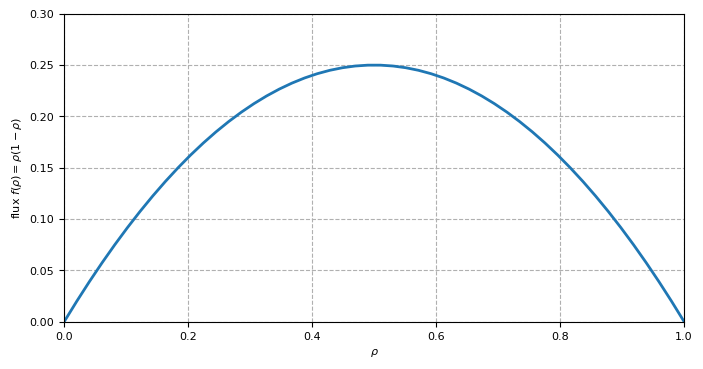

In [476]:
rho = np.linspace(0,1)
f = rho*(1.-rho)
plt.plot(rho,f,linewidth=2)
plt.xlabel(r'$\rho$'); plt.ylabel(r'flux $f(\rho) = \rho(1-\rho)$');
plt.ylim(0,0.3); plt.xlim(0,1); plt.grid(linestyle='--');

This plot demonstrates how the flux of a section of road is affected. BEcause flow rate depends on density, the extremes are both 0 as they are either static traffic or an empty road. In between the linear vel. dependence from the rgo(1-rho eqn is shown). so the maximum flux is at the middle of the graph where density is high but so is car speed.

In [477]:
def jam(rho_l=0.4,t=0.1):
    shock_speed = -rho_l
    #shock speed can be derived to just be dependent on incoming density
    shock_location = t*shock_speed
    #shock location varies with speed
    fig, axes = plt.subplots(1,2,figsize=figsize)
    #plots two horizontal lines at 1 and the chosen density of incoming traffic
    axes[0].plot([-1,shock_location],[rho_l,rho_l],'k',lw=2)
    #this line below specifically plots a verticle line which represents the shock
    axes[0].plot([shock_location,shock_location],[rho_l,1.],'k',lw=2)
    axes[0].plot([shock_location,1.],[1.,1.],'k',lw=2)
    axes[0].set_xlabel('$x$'); axes[0].set_ylabel(r'$\rho$'); 
    axes[0].set_xlim(-0.2,0.2); axes[0].set_ylim(0,1.1)
    traffic_LWR.plot_car_trajectories(rho_l,1.,axes[1]); 
    axes[1].set_ylim(0,1); axes[0].set_title(r'$t= $'+str(t))
    plt.xlabel('$x$'); plt.ylabel(r'$t$');
    plt.show()
    
interact(jam,
         rho_l=FloatSlider(min=0.,max=0.9,value=0.2,description=r'rho_l'),
         t=FloatSlider(min=0.,max=1.,value=0.2));


interactive(children=(FloatSlider(value=0.2, description='rho_l', max=0.9), FloatSlider(value=0.2, description…

These plots show the two key ideas behind the Rankine–Hugoniot condition for a traffic jam. The left hand graph is simply for a set time t, what is the density of cars at a position x on the road, this depends on rho_l (as it defines the shock wave speed) and the time after the shock wave begins t (i.e. as t increases it moves further back). 
The right had graph is how the cars move wrt time. s(speed of shock wave) is dependent on in flow density (rho_l) so if rho_l increases then the traffic backs up more quickly. The traffic above 0 is assumed to be static i.e. no change in x over time. The vehicles left of 0 are less dense, and move until they hit the distance behind the car infront where they need to stop. plotting these distances as the traffic accumulates. By increasing rho_l you can increases the number of cars approaching in the space -0.6 to 0. This not only forces the incoming cars closer together but increases the rate the shock wave moves at. The shockwave is the red line on the RHS graph.

In [478]:
def green_light(rho_r=0.,t=0.1):
    rho_l = 0.1
    left_edge = -t
    right_edge = -t*(2*rho_r - 1)
    fig, axes = plt.subplots(1,2,figsize=figsize)
    axes[0].plot([-1,left_edge],[rho_l,rho_l],'k',lw=2)
    axes[0].plot([left_edge,right_edge],[rho_l,rho_r],'k',lw=2)
    axes[0].plot([right_edge,1.],[rho_r,rho_r],'k',lw=2)
    axes[0].set_xlabel('$x$'); axes[0].set_ylabel(r'$\rho$');
    axes[0].set_xlim(-1,1);  axes[0].set_ylim(-0.1,1.1)
    plt.xlabel('$x$'); plt.ylabel(r'$t$');
   
    traffic_LWR.plot_car_trajectories(0.7,rho_r,axes[1],t=t,xmax=1.); 
    axes[1].set_ylim(0,1)
    plt.show()    

interact(green_light,
         rho_r=FloatSlider(min=0.,max=0.9,value=0.,description=r'$\rho_r$'),
         t=FloatSlider(min=0.,max=1.));

interactive(children=(FloatSlider(value=0.0, description='$\\rho_r$', max=0.9), FloatSlider(value=0.0, descrip…

These graphs are similar to the case before, except now it is reversed. This can be viewd as the front of a traffic jam or slow region, where the traffic has open road and can speed up. This is a bit stranger though as its not just a case of stopping its how one car accelerates then a next and so on its a ripple effect and takes time. 

The math dictates that for a decrease in density it must be a shockwave. ANd for an increasing density it must be a rarefraction.

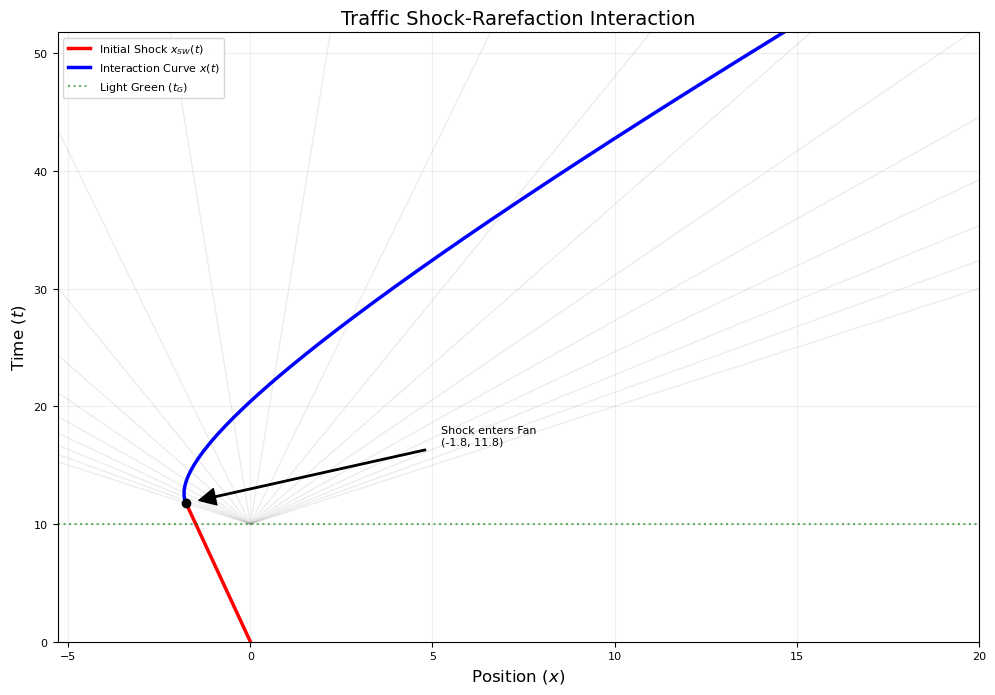

In [479]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters 
rho_in = 0.15
t_R = 0
t_delay = 10
t_G = t_R + t_delay
D = 0
s = -rho_in  # Shock speed

# Transition Point
t_star = (t_G + s * t_R) / (1 + s)
x_star = D + s * (t_star - t_R)

# Ranges
t_max = t_star + 40
t_fan = np.linspace(t_G, t_max, 100)

plt.figure(figsize=(10, 7))

# Rarefaction Fan 
# These represent the information waves spreading out from the green light
fan_slopes = np.linspace(-1, 1, 20) 
for slope in fan_slopes:
    # x = v*t -> in this plot x = D + slope * (t - t_G)
    x_f = D + slope * (t_fan - t_G)
    plt.plot(x_f, t_fan, color='gray', alpha=0.15, lw=1)

# Initial Shock Wave
t_sw = np.linspace(t_R, t_star, 100)
x_sw = D + s * (t_sw - t_R)
plt.plot(x_sw, t_sw, 'r', lw=2.5, label='Initial Shock $x_{SW}(t)$')

# Transition Region
t_trans = np.linspace(t_star, t_max, 400)
lin_term = (1 - 2 * rho_in) * (t_trans - t_G)
sqrt_inner = (s * (t_R - t_G) * (t_trans - t_G)) / (1 + s)
decay_term = - 2 * (1 - rho_in) * np.sqrt(sqrt_inner)
x_t = lin_term + D + decay_term
plt.plot(x_t, t_trans, 'b', lw=2.5, label='Interaction Curve $x(t)$')

# Annotations & Formatting
plt.scatter([x_star], [t_star], color='black', zorder=5)
plt.annotate(f'Shock enters Fan\n({x_star:.1f}, {t_star:.1f})', 
             xy=(x_star, t_star), xytext=(x_star + 7, t_star + 5),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1))

plt.axhline(t_G, color='green', ls=':', alpha=0.6, label='Light Green ($t_G$)')
plt.title('Traffic Shock-Rarefaction Interaction', fontsize=14)
plt.xlabel('Position ($x$)', fontsize=12)
plt.ylabel('Time ($t$)', fontsize=12)
plt.xlim(x_star * 3, 20)
plt.ylim(0, t_max)
plt.grid(True, alpha=0.2)
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()


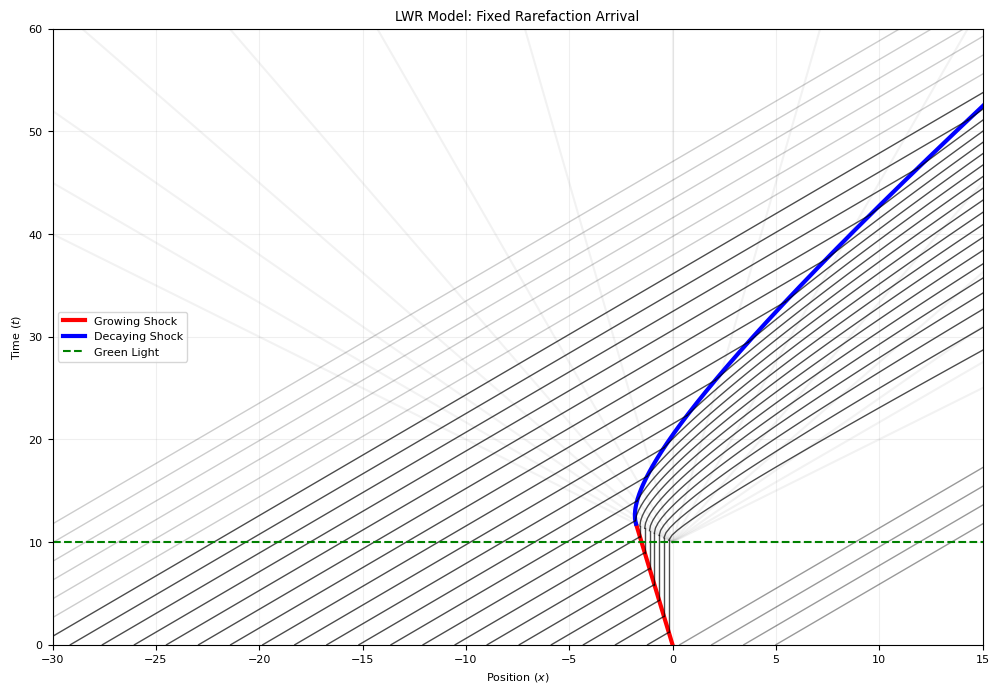

In [480]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq

#  Parameters 
rho_in = 0.15
v_in = 1 - rho_in
t_G = 10
s = -rho_in
t_star = t_G / (1 + s)
t_max = 60

def get_x_shock(t):
    if t < t_star:
        return s * t
    else:
        # Decaying interaction formula
        lin = (1 - 2*rho_in) * (t - t_G)
        sqrt_term = - 2 * (1 - rho_in) * np.sqrt(max(0, (s * -t_G * (t - t_G)) / (1 + s)))
        return lin + sqrt_term

plt.figure(figsize=(12, 8))

# Background Fan of rarefraction
t_fan_plot = np.linspace(t_G, t_max, 100)
for slope in np.linspace(-1, 1, 15):
    plt.plot(slope * (t_fan_plot - t_G), t_fan_plot, color='gray', alpha=0.1)

# Plotting the Shocks
t_range = np.linspace(0, t_max, 500)
x_shocks = [get_x_shock(t) for t in t_range]
plt.plot(np.array(x_shocks)[t_range <= t_star], t_range[t_range <= t_star], 'r', lw=3, label='Growing Shock')
plt.plot(np.array(x_shocks)[t_range > t_star], t_range[t_range > t_star], 'b', lw=3, label='Decaying Shock')

# Corrected Car Trajectories
car_starts = np.linspace(-40, 5, 30)
for x0 in car_starts:
    if x0 >= 0:
        plt.plot([x0, x0 + v_in * t_max], [0, t_max], 'k-', lw=1, alpha=0.4)
        continue

    try:
        t_hit = brentq(lambda t: (x0 + v_in * t) - get_x_shock(t), 0, t_max)
        x_hit = x0 + v_in * t_hit
        
        plt.plot([x0, x_hit], [0, t_hit], 'k-', lw=1, alpha=0.7)

        # The car starts moving when the rarefaction wave (speed -1) hits it
        # Rarefaction wave line: x = -1 * (t - t_G) -> t = t_G - x
        t_starts_moving = max(t_hit, t_G - x_hit)
        
        if t_hit < t_starts_moving:
            # Vertical segment (stopped in jam)
            plt.plot([x_hit, x_hit], [t_hit, t_starts_moving], 'k-', lw=1, alpha=0.7)

        # C. ACCELERATION (Following the Fan)
        t_accel = np.linspace(t_starts_moving, t_max, 100)
        # Solve for C so it starts at (x_hit, t_starts_moving)
        dt_accel = t_starts_moving - t_G
        if dt_accel > 0:
            sqrt_C = (dt_accel - x_hit) / (2 * np.sqrt(dt_accel))
            x_accel = (t_accel - t_G) - 2 * sqrt_C * np.sqrt(t_accel - t_G)
            # Ensure continuity and physical bounds
            plt.plot(np.maximum(x_hit, x_accel), t_accel, 'k-', lw=1, alpha=0.7)
        else:
            # For the first car at the stop line
            plt.plot([0, t_max - t_G], [t_G, t_max], 'k-', lw=1, alpha=0.7)

    except ValueError:
        plt.plot([x0, x0 + v_in * t_max], [0, t_max], 'k-', lw=1, alpha=0.2)

plt.axhline(t_G, color='g', ls='--', label='Green Light')
plt.xlim(-30, 15); plt.ylim(0, t_max)
plt.ylabel('Time ($t$)'); plt.xlabel('Position ($x$)');
plt.title("LWR Model: Fixed Rarefaction Arrival")
plt.legend(); plt.grid(alpha=0.2); plt.show()


# MATHS EXPLAINED


 1. TThe LWR Model

The Lighthill-Whitham-Richards (LWR) model describes traffic as a continuous fluid. The fundamental governing equation is the **Conservation of Vehicles**, expressed by the continuity equation:

$$\frac{\partial\rho}{\partial t} + \frac{\partial\phi}{\partial x} = 0$$

where $\rho$ = traffic density and $\phi(\rho) = \rho v$ is the traffic flux. Assuming a Greenshields model where velocity $v = 1 - \rho$, the flux becomes $\phi = \rho(1 - \rho)$. Applying the chain rule to the continuity equation gives. This assumes velocity and density be expressed as a fraction of the maximum velocity and density possible for the road. 

The continuity equation can be rewritten as:

$$\frac{\partial\rho}{\partial t} + \frac{\phi}{d\rho}\frac{\partial\rho}{\partial x} = 0$$

We can write generally
 $$d\rho = dt \frac{\partial \rho}{\partial t} + dx \frac{\partial \rho}{\partial x}$$

 and we rearrange to find,

 $$\frac{d\rho}{dt} = \frac{\partial \rho}{\partial t} +\frac{dx}{dt}\frac{\partial\rho}{\partial x} $$

setting $$\frac{d\rho}{dt} = 0 $$ defines the characteristic lines, i.e. lines where the density remains constant. We notice that from the origional form and this new form we can write

$$\frac{d\rho}{dt} = \frac{d\phi}{d\rho}$$

Substituting in for flux in we can define our  $$c(\rho) = \frac{d\phi}{d\rho} = 1 - 2\rho$$. So C is our characteristic function and it is continuous in $\rho$.

---

# 2. The Riemann Problem: Green Light Activation

When a traffic light turns green ($t_G$) at position $D$, it creates a jump in density from $\rho_{in} = 1$ (stopped) to $\rho_{out} = 0$ (empty road initially afterwards). This jump resolves into a **Rarefaction Fan**. This comes from how our characteristic function is continuous in $\rho$. We can simply multiply both sides by dt,

$$dx = dt(1-2\rho)$$

Integrating gives
$$x_{fan}(\rho, t) = D + (1 - 2\rho)(t - t_G)$$

Here $D$ and $t_G$ have been added to position the fan at distance D and to occur at a specific greenlight time $t_G$.

Because density varies continuously from 1 to $\rho_{in}$ within this fan, vehicles do not accelerate instantly but follow the fan's spreading characteristics.

---

# 3. The Shock Wave: Rankine-Hugoniot Condition

The occurrence of a shockwave in the LWR model represents a mathematical and physical discontinuity in traffic density $\rho$. This arises when the **characteristic curves** intersect (This is for a time after the light switches on as the light itself is a random spontaneous occurance so before the light doesnt matter which is why the fan at the origin is allowed).

#### The Mathematical Condition
The characteristic speed is given by the derivative of the flux function:
$$c(\rho) = \frac{d\phi}{d\rho} = 1 - 2\rho$$

A shock forms whenever the density behind a point is greater than the density in front ($\rho_{behind} > \rho_{front}$). Because $c(\rho)$ decreases as $\rho$ increases, the faster characteristics from the lower-density region upstream inevitably "catch up" to the slower characteristics of the high-density jam. This is clearer if The full greenshields formula is used:

$$u(\rho)=v_{max}(1-\frac{\rho}{\rho_{max}}) ,  c(\rho)=v_{max}(1-\frac{2 \rho}{\rho_{max}})$$

so as $\rho$ increases the angle of the constant density line changes. For a lower density the line becomes near to the max velocity, whilst a jam becomes verticle, or negative. So you have a positive line and a negative line. The negative line originates within the initial jam and the positive just outside the jam. This does not work as they would intersect. 

At the point of intersection, the density becomes multi-valued, which is physically impossible. To maintain the **Conservation of Vehicles**, a discrete jump (discontinuity) must be introduced.

#### The Rankine-Hugoniot Jump Condition
The velocity of this discontinuity, $s$, is determined by the ratio of the change in flux to the change in density across the interface:

$$s = \frac{\Delta \phi}{\Delta \rho} = \frac{\phi_{out} - \phi_{in}}{\rho_{out} - \rho_{in}}$$

Which is the key model for the shockwave.
Out and in order doesnt matter as the -1 factors on numerator and denominator cancel.

---

# 4. Shockwave meets green wave

We know that the shockwave will likely meet the greenwave in the scenario where traffic begins to move again. The faster moving charactersitic of the greenwave will catch the slower shock and therefore we need to find what happens in this region. The simplest case is to take our two equations: 

Shock wave:
$$s = \frac{\Delta \phi}{\Delta \rho} = \frac{\phi_{out} - \phi_{in}}{\rho_{out} - \rho_{in}}$$

and greenwave:
$$x_{fan}(\rho, t) = D + (1 - 2\rho)(t - t_G)$$


We know that $\phi_{out}$ depends on the density of the outgoing traffic. So we can substitute out function for the green wave in. Re-arranging for $\rho$ which is actually $\rho(x,t)$, we get:

$$\rho(x,t) =\frac{1}{2}(1-\frac{x_{GW}-D}{t-t_G})$$

Which we substitue in to the shockwave velocity eqn, using $s=\frac{dx}{dt}$, to get

$$\frac{dx(t)}{dt}-\frac{1}{2(t-t_G)}x(t)=(\frac{1}{2}-\rho_in)-\frac{D}{2(t-t_G)}$$

Which is a 1st order ODE. Using the integrating factor method, we solve it to find that:

$$x(t) = (1-2\rho_in)(t-t_G)+D-2(1-\rho_{in})\sqrt{\frac{s(t_R-t_G)(t-t_G)}{1+s}}$$

where

$$s=-\rho_{in}$$

This is because the $\rho_{out} = 1$ as traffic is static. And therefore the flux is 0 coming out of the jam. so we get:

$$s=\frac{0-\rho_{in}(1-\rho_{in})}{1-\rho_{in}}$$

which is just $-\rho_{in}$ as the factors cancel.

---

# 5. Finding the car intersects

Two methods can be used here as the eqn is not transcendental. The algebraic method and brentq. The algebraic methid is relatively straight forward as you just use the quadratic formula. But it is messy, and requires the removal of "ghost solutions" and a limit on the code. 

Brentq does this automatically and is a claver numerical method which accurately finds the solution. method choice is up to the coder. But the algebra(below) is messy.

---

# 6. Dissolution of the Shockwave

The shockwave physically can never dissolve and exist until t= infinity according to the LWR model.  The reason for this is that it requires the shockwave to reach the last arm of the rarefraction fan. This is physically impossible in this model. However. It doesnt matter unless the density is constant. As if the density drops for a period large enough the flow basically reaches normal flow before another car catches up. This model uses alot of assumptions such as constant density and velocity therefore before. It therefore breaks in some extremes. To solve this an "error" must be added to give a finite value. this can be set very low which gives the velocity as practically the normal velocity of the traffic.


---

# 7. AI Disclosure & Contributions
[cite_start]In accordance with course guidance, **Generative AI (Gemini)** was used to assist in the Python implementation of the numerical root-finding logic as a starting point above, and the piecewise trajectory visualization[cite: 9]. All physical derivations and were done by hand and then checked against AI to ensure no errors. 

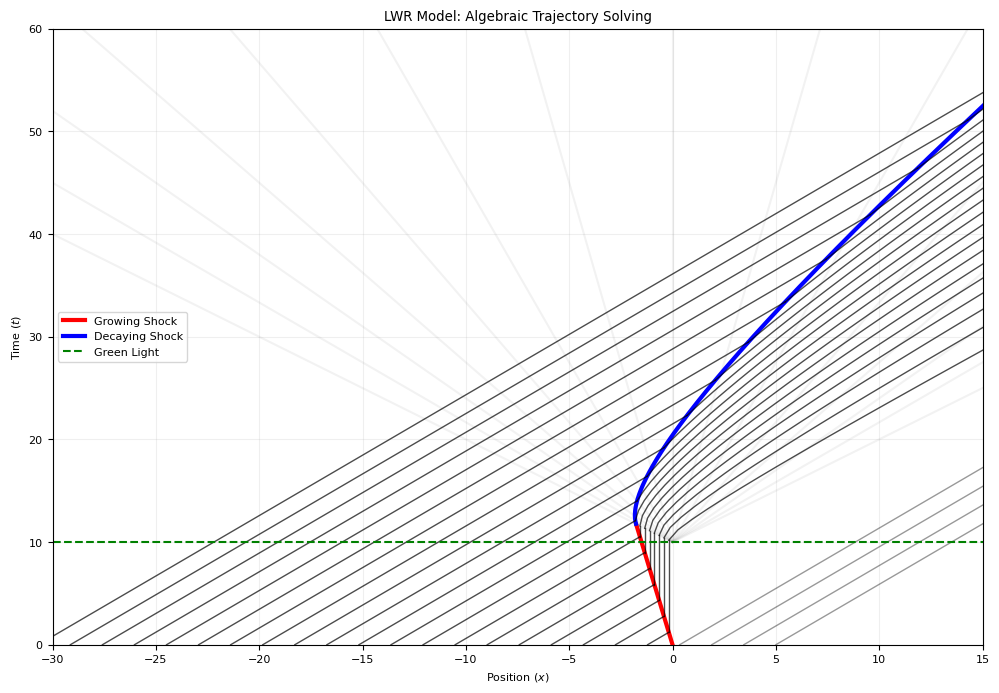

In [481]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters 
rho_in = 0.15
v_in = 1 - rho_in
t_G = 10
s_0 = -rho_in  # Initial shock speed
t_star = t_G / (1 + s_0)
t_max = 60

def get_x_shock(t):
    if t < t_star:
        return s_0 * t
    else:
        # Decaying interaction formula
        lin = (1 - 2*rho_in) * (t - t_G)
        # K constant from the derivation: 2*(1-rho_in)*sqrt(s_0*-t_G / (1+s_0))
        k_const = 2 * (1 - rho_in) * np.sqrt((s_0 * -t_G) / (1 + s_0))
        return lin - k_const * np.sqrt(max(0, t - t_G))

plt.figure(figsize=(12, 8))

# 1. Background Fan
t_fan_plot = np.linspace(t_G, t_max, 100)
for slope in np.linspace(-1, 1, 15):
    plt.plot(slope * (t_fan_plot - t_G), t_fan_plot, color='gray', alpha=0.1)

# 2. Plotting the Shocks
t_range = np.linspace(0, t_max, 500)
x_shocks = [get_x_shock(t) for t in t_range]
plt.plot(np.array(x_shocks)[t_range <= t_star], t_range[t_range <= t_star], 'r', lw=3, label='Growing Shock')
plt.plot(np.array(x_shocks)[t_range > t_star], t_range[t_range > t_star], 'b', lw=3, label='Decaying Shock')

# 3. ALGEBRAIC CAR TRAJECTORIES
car_starts = np.linspace(-40, 5, 30)
for x0 in car_starts:
    if x0 >= 0:
        plt.plot([x0, x0 + v_in * t_max], [0, t_max], 'k-', lw=1, alpha=0.4)
        continue

    # --- ALGEBRAIC SOLVER START ---
    t_hit = None
    
    # Step A: Check intersection with Linear Growing Shock (t < t_star)
    # x0 + v_in*t = s_0*t  => t = -x0 / (v_in - s_0)
    t_linear = -x0 / (v_in - s_0)
    
    if t_linear <= t_star:
        t_hit = t_linear
    else:
        # Step B: Solve Quadratic for Decaying Shock (t > t_star)
        # Equation: x0 + v_in*t = (1-2rho)(t-t_G) - K*sqrt(t-t_G)
        # Let T = t - t_G. 
        # Solve: x0 + v_in(T + t_G) = (1-2rho)T - K*sqrt(T)
        
        K = 2 * (1 - rho_in) * np.sqrt((s_0 * -t_G) / (1 + s_0))
        V_diff = (1 - 2*rho_in) - v_in
        Const = - (x0 + v_in * t_G)
        
        # This leads to: V_diff * T + Const = K * sqrt(T)
        # Square it: (V_diff)^2 * T^2 + (2*V_diff*Const - K^2) * T + Const^2 = 0
        a = V_diff**2
        b = (2 * V_diff * Const) - K**2
        c = Const**2
        
        discriminant = b**2 - 4*a*c
        if discriminant >= 0:
            T_roots = [(-b + np.sqrt(discriminant)) / (2*a), 
                       (-b - np.sqrt(discriminant)) / (2*a)]
            
            valid_ts = []
            for T in T_roots:
                if T >= 0:
                    t_cand = T + t_G
                    # Verify it's not a "ghost" root from squaring
                    # Check if x_veh(t) approx equals x_shock(t)
                    if abs((x0 + v_in * t_cand) - get_x_shock(t_cand)) < 0.1:
                        valid_ts.append(t_cand)
            
            if valid_ts:
                t_hit = min(valid_ts)
    # --- ALGEBRAIC SOLVER END ---

    if t_hit is not None and t_hit < t_max:
        x_hit = x0 + v_in * t_hit
        plt.plot([x0, x_hit], [0, t_hit], 'k-', lw=1, alpha=0.7)
        
        # Plotting the rest of the trajectory (Stopped + Acceleration)
        t_starts_moving = max(t_hit, t_G - x_hit)
        if t_hit < t_starts_moving:
            plt.plot([x_hit, x_hit], [t_hit, t_starts_moving], 'k-', lw=1, alpha=0.7)
        
        t_accel = np.linspace(t_starts_moving, t_max, 50)
        dt_accel = t_starts_moving - t_G
        if dt_accel > 0:
            sqrt_C = (dt_accel - x_hit) / (2 * np.sqrt(dt_accel))
            x_accel = (t_accel - t_G) - 2 * sqrt_C * np.sqrt(t_accel - t_G)
            plt.plot(np.maximum(x_hit, x_accel), t_accel, 'k-', lw=1, alpha=0.7)

plt.axhline(t_G, color='g', ls='--', label='Green Light')
plt.xlim(-30, 15); plt.ylim(0, t_max)
plt.ylabel('Time ($t$)'); plt.xlabel('Position ($x$)')
plt.title("LWR Model: Algebraic Trajectory Solving")
plt.legend(); plt.grid(alpha=0.2); plt.show()

Below is the brentq method with the added shockwave dissolution limit. The limit is set here as 0.9999 the incoming velocity. 

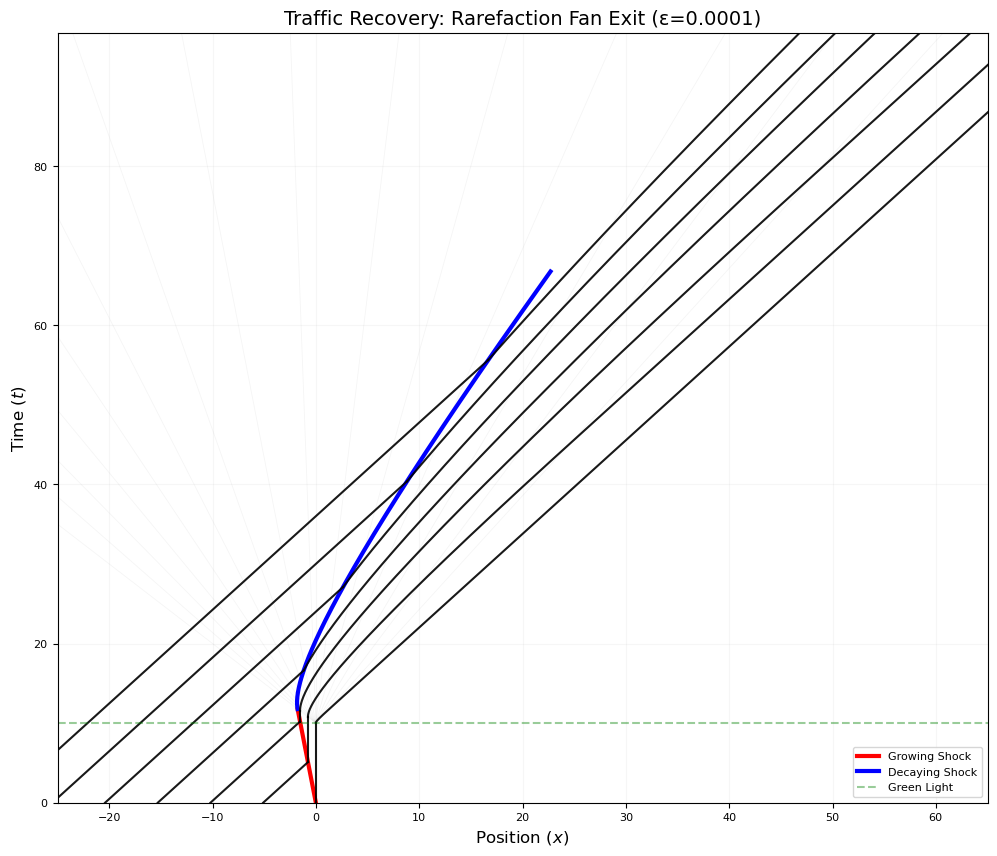

In [489]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Parameters ---
rho_in = 0.15
v_in = 1 - rho_in
t_G = 10
s_0 = -rho_in  
t_star = t_G / (1 + s_0)
epsilon = 0.0001 

# --- 2. Dissolution Math ---
A_shock = (1 - 2*rho_in)
K_const = 2 * (1 - rho_in) * np.sqrt((s_0 * -t_G) / (1 + s_0))
V_target = v_in - epsilon
dt_diss = ( (0.5 * K_const) / (A_shock - V_target) )**2
t_diss = t_G + dt_diss

# Buffer to see the exit from the fan
t_max = t_diss + 30 

def get_x_shock(t):
    if t < t_star: return s_0 * t
    elif t <= t_diss:
        dt = t - t_G
        return A_shock * dt - K_const * np.sqrt(max(0, dt))
    return None 

plt.figure(figsize=(12, 10))

# --- 3. Background: The Rarefaction Fan ---
t_fan_plot = np.linspace(t_G, t_max, 200)
for r in np.linspace(rho_in, 1.0, 15):
    slope = 1 - 2 * r
    plt.plot(slope * (t_fan_plot - t_G), t_fan_plot, color='gray', alpha=0.08, lw=0.6)

# --- 4. The Shockwave ---
t_r1 = np.linspace(0, t_star, 100)
plt.plot([get_x_shock(t) for t in t_r1], t_r1, 'r', lw=3, label='Growing Shock')
t_r2 = np.linspace(t_star, t_diss, 500)
plt.plot([get_x_shock(t) for t in t_r2], t_r2, 'b', lw=3, label='Decaying Shock')

# --- 5. Natural Trajectories with Fan Exit ---
arrival_times = np.arange(0, 60, 6) 
for t_arr in arrival_times:
    x0 = -v_in * t_arr
    
    # Standard intersection solver for the shock
    t_hit = None
    t_lin = -x0 / (v_in - s_0)
    if t_lin <= t_star: t_hit = t_lin
    else:
        a, b, c = (A_shock-v_in)**2, (2*(A_shock-v_in)*(-(x0+v_in*t_G)))-K_const**2, (-(x0+v_in*t_G))**2
        disc = b**2 - 4*a*c
        if disc >= 0:
            roots = [(-b + np.sqrt(disc))/(2*a), (-b - np.sqrt(disc))/(2*a)]
            v_ts = [T + t_G for T in roots if T >= 0 and get_x_shock(T + t_G) is not None]
            if v_ts: t_hit = min(v_ts)

    if t_hit is not None:
        # Phase A: Incoming to Shock
        x_hit = x0 + v_in * t_hit
        plt.plot([x0, x_hit], [0, t_hit], 'k-', lw=1.5, alpha=0.9) 
        
        # Phase B: Stopped in Jam
        t_mov = max(t_hit, t_G - x_hit)
        if t_hit < t_mov:
            plt.plot([x_hit, x_hit], [t_hit, t_mov], 'k-', lw=1.5, alpha=0.9) 
        
        # Phase C: Numerical Integration through Fan and beyond
        curr_t, curr_x = t_mov, x_hit
        dt_step = 0.1
        path_x, path_t = [curr_x], [curr_t]
        
        while curr_t < t_max:
            # Inside the fan, velocity depends on x/t
            # At the edge of the fan, it must equal v_in
            if curr_t > t_G:
                v_fan = 0.5 * (curr_x / (curr_t - t_G) + 1)
                # If fan velocity reaches v_in, the car "breaks away"
                v = min(v_in, max(0, v_fan))
            else:
                v = 0
            
            curr_x += v * dt_step
            curr_t += dt_step
            path_x.append(curr_x)
            path_t.append(curr_t)
            
        plt.plot(path_x, path_t, 'k-', lw=1.5, alpha=0.9)

# --- 6. Formatting ---
plt.axhline(t_G, color='green', ls='--', alpha=0.4, label='Green Light')
plt.xlim(-25, 65); plt.ylim(0, t_max)
plt.xlabel("Position ($x$)", fontsize=12); plt.ylabel("Time ($t$)", fontsize=12)
plt.title(f"Traffic Recovery: Rarefaction Fan Exit (ε={epsilon})", fontsize=14)
plt.legend(loc='lower right')
plt.grid(alpha=0.1)
plt.show()